# Vendor Performance Analytics — Part 2
## Exploratory Data Analysis → Statistics → Machine Learning

**Author:** Shivansh Nigam
**Input:** `vendor_sales_summary_clean.csv` — the analysis-ready, brand-level dataset produced in **Part 1 (SQL + Python)**.

**Structure:**
1. Exploratory Data Analysis (EDA)
2. Inferential Statistics (t-test, correlation)
3. Machine Learning — KMeans clustering (vendor performance tiers)
4. Machine Learning — Linear Regression (drivers of profit margin)
5. Save outputs, validate against the production reference, business conclusions


In [1]:
import json

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Libraries loaded.")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\shiva\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\shiva\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\shiva\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\shiva\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\shiva\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\shiva\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 758, in start
    self.io_lo

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Libraries loaded.


In [2]:
import os

# Prefer the file produced by Part 1; fall back to the Excel "Data" sheet
# so this notebook can also run standalone.
if os.path.exists("vendor_sales_summary_clean.csv"):
    df_cleaned = pd.read_csv("vendor_sales_summary_clean.csv")
    print("Loaded vendor_sales_summary_clean.csv (output of Part 1)")
else:
    df_cleaned = pd.read_excel("Vendor_Performance_Dashboard.xlsx", sheet_name="Data")
    print("Part 1 output not found — loaded the Data sheet from the dashboard workbook instead")

print("Rows:", len(df_cleaned), "| Columns:", len(df_cleaned.columns))
print("\nFirst 3 rows:\n")
print(df_cleaned.head(3).to_string(index=False))


Loaded vendor_sales_summary_clean.csv (output of Part 1)
Rows: 8564 | Columns: 18

First 3 rows:

 VendorNumber     VendorName  Brand             Description  Volume  PurchasePrice  ActualPrice  TotalPurchaseQuantity  TotalPurchaseDollars  TotalSalesQuantity  TotalSalesDollars  TotalSalesPrice  TotalExciseTax  FreightCost  GrossProfit  ProfitMargin  StockTurnover  UnsoldCapital
          116 VENDOR_116 INC   6528 Liquor Description 6528   750.0      42.219498    54.838022                    124           5235.217796                 115        6306.372515        54.838022      237.084169   342.056038  1071.154719     16.985275       0.927419     379.975485
            6 M S WALKER INC   4060 Liquor Description 4060  1000.0      51.098497    76.038385                     70           3576.894821                  70        5322.686951        76.038385      138.932594   113.027955  1745.792130     32.799076       1.000000       0.000000
           94  VENDOR_94 INC   6209 Liquor Descriptio

---
## 1. Exploratory Data Analysis (EDA)


In [3]:
print("Shape:", df_cleaned.shape)
print("\nData types:\n", df_cleaned.dtypes)
print("\nMissing values:", df_cleaned.isnull().sum().sum(), "total nulls")

print("\nKey stats:")
for col in ["ProfitMargin", "TotalSalesDollars", "GrossProfit", "StockTurnover", "UnsoldCapital"]:
    s = df_cleaned[col]
    print(f"  {col}: mean={s.mean():,.2f}, median={s.median():,.2f}, min={s.min():,.2f}, max={s.max():,.2f}")


Shape: (8564, 18)

Data types:
 VendorNumber               int64
VendorName                   str
Brand                      int64
Description                  str
Volume                   float64
PurchasePrice            float64
ActualPrice              float64
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity         int64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
GrossProfit              float64
ProfitMargin             float64
StockTurnover            float64
UnsoldCapital            float64
dtype: object

Missing values: 0 total nulls

Key stats:
  ProfitMargin: mean=20.82, median=21.19, min=0.01, max=42.99
  TotalSalesDollars: mean=172,705.81, median=14,530.33, min=49.55, max=4,529,946.03
  GrossProfit: mean=38,584.18, median=2,758.78, min=0.54, max=1,862,808.92
  StockTurnover: mean=0.90, median=0.90, min=0.57, max=1.10
  UnsoldCapital: mean=13,596.37, med

In [4]:
print("Unique vendors:", df_cleaned["VendorName"].nunique())
print("Unique brands:", df_cleaned["Brand"].nunique())

print("\nVendors with the most brand-level rows:")
for vendor, count in df_cleaned["VendorName"].value_counts().head().items():
    print(f"  {vendor}: {count} rows")


Unique vendors: 119
Unique brands: 8544

Vendors with the most brand-level rows:
  MARTIGNETTI COMPANIES: 1094 rows
  M S WALKER INC: 655 rows
  ULTRA BEVERAGE COMPANY LLP: 627 rows
  PERFECTA WINES: 582 rows
  E & J GALLO WINERY: 443 rows


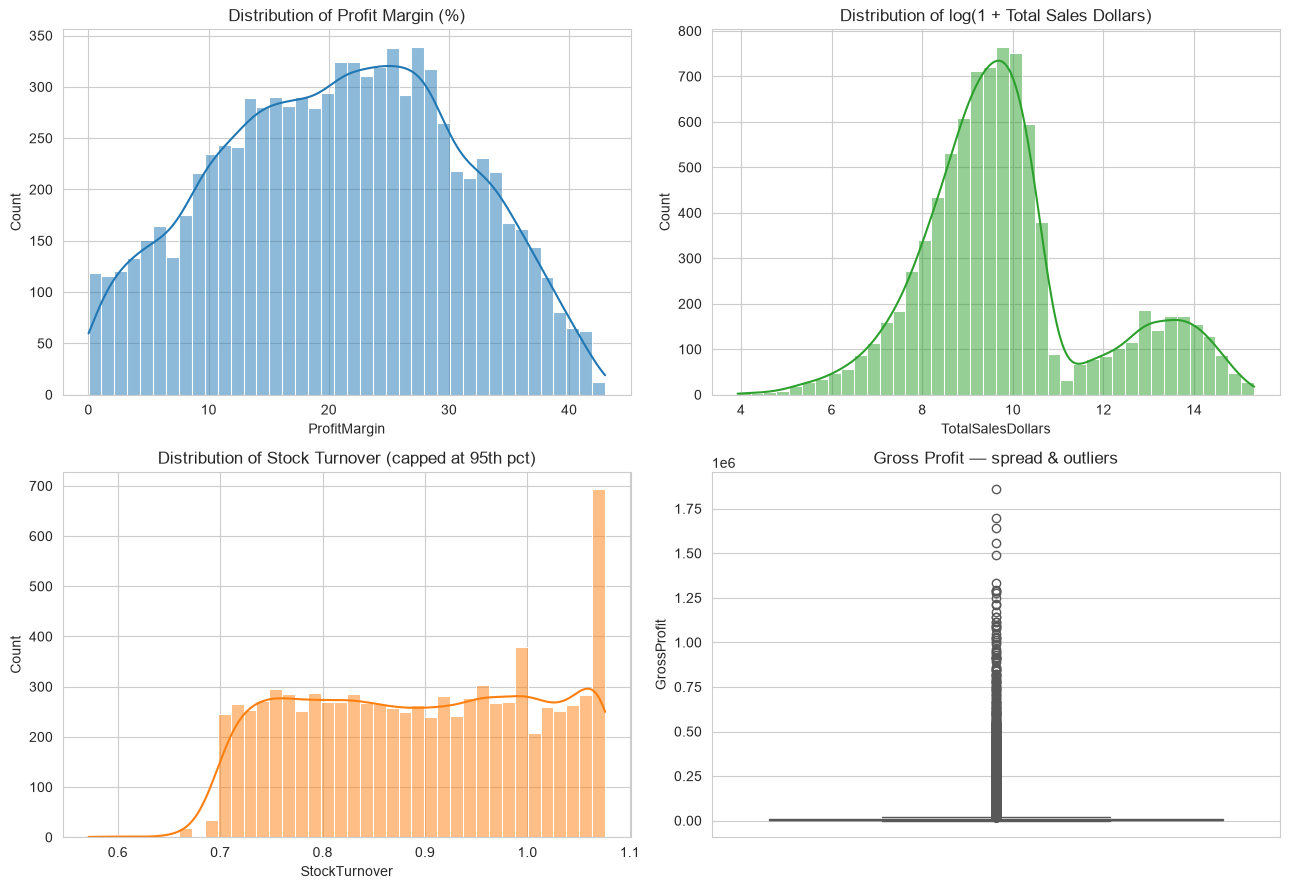

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df_cleaned["ProfitMargin"], bins=40, kde=True, ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Distribution of Profit Margin (%)")

sns.histplot(np.log1p(df_cleaned["TotalSalesDollars"]), bins=40, kde=True, ax=axes[0, 1], color="#2ca02c")
axes[0, 1].set_title("Distribution of log(1 + Total Sales Dollars)")

sns.histplot(df_cleaned["StockTurnover"].clip(upper=df_cleaned["StockTurnover"].quantile(0.95)),
             bins=40, kde=True, ax=axes[1, 0], color="#ff7f0e")
axes[1, 0].set_title("Distribution of Stock Turnover (capped at 95th pct)")

sns.boxplot(y=df_cleaned["GrossProfit"], ax=axes[1, 1], color="#9467bd")
axes[1, 1].set_title("Gross Profit — spread & outliers")

plt.tight_layout()
plt.show()


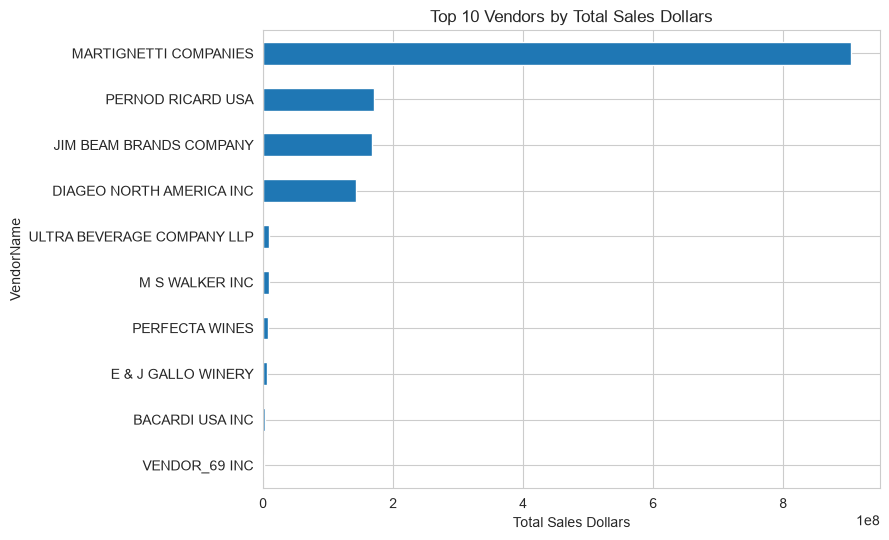

In [6]:
top_vendors = (
    df_cleaned.groupby("VendorName")["TotalSalesDollars"].sum().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
top_vendors.sort_values().plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Top 10 Vendors by Total Sales Dollars")
ax.set_xlabel("Total Sales Dollars")
plt.tight_layout()
plt.show()


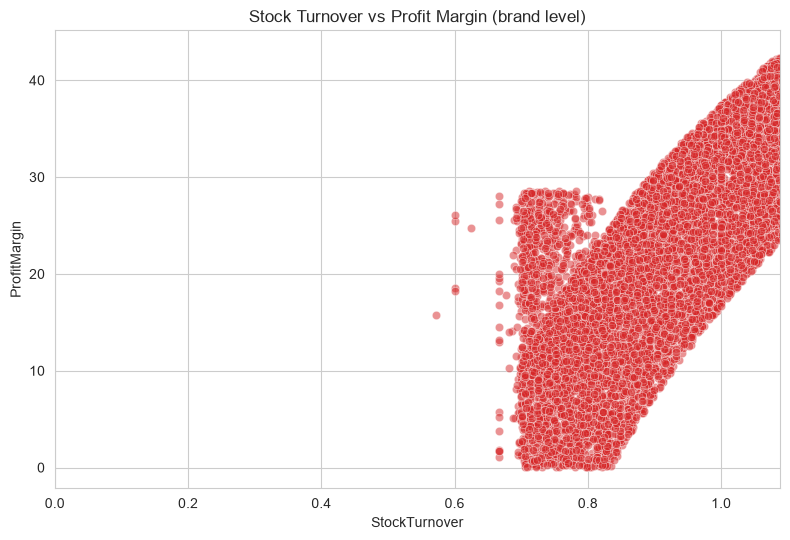

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(
    data=df_cleaned, x="StockTurnover", y="ProfitMargin",
    alpha=0.5, ax=ax, color="#d62728"
)
ax.set_xlim(0, df_cleaned["StockTurnover"].quantile(0.98))
ax.set_title("Stock Turnover vs Profit Margin (brand level)")
plt.tight_layout()
plt.show()


**EDA takeaway:** Sales dollars are heavily right-skewed (a handful of vendors dominate volume), profit margins cluster broadly but with a long tail, and there's no obvious strong linear pattern between stock turnover and margin at the brand level — motivating the vendor-level aggregation and multivariate approaches (clustering, regression) used next.


---
## 2. Statistics

Rolls brand-level rows up to one row per vendor first, since the business question ("is this vendor a low performer?") is a vendor-level question.


In [8]:
def vendor_level_aggregate(df):
    """Roll brand-level rows up to one row per vendor for clustering/stats."""
    agg = df.groupby("VendorName").agg(
        TotalPurchaseDollars=("TotalPurchaseDollars", "sum"),
        TotalSalesDollars=("TotalSalesDollars", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        FreightCost=("FreightCost", "sum"),
        StockTurnover=("StockTurnover", "mean"),
        ProfitMargin=("ProfitMargin", "mean"),
        UnsoldCapital=("UnsoldCapital", "sum"),
        BrandCount=("Brand", "nunique"),
        AvgPurchasePrice=("PurchasePrice", "mean"),
        AvgActualPrice=("ActualPrice", "mean"),
    ).reset_index()
    return agg

vendor_df = vendor_level_aggregate(df_cleaned)
print("Vendor-level rows:", len(vendor_df))
print("\nSample vendor record:")
sample = vendor_df.iloc[0]
print(f"  {sample['VendorName']}: Total Sales = ${sample['TotalSalesDollars']:,.2f}, "
      f"Gross Profit = ${sample['GrossProfit']:,.2f}, Profit Margin = {sample['ProfitMargin']:.2f}%")


Vendor-level rows: 119

Sample vendor record:
  ADAMBA IMPORTS INTL INC: Total Sales = $340,160.36, Gross Profit = $67,783.06, Profit Margin = 18.76%


### 2.1 Inferential statistics — Welch's t-test

**Question:** Do higher-sales-volume vendors actually earn better profit margins, or is that impression driven by a handful of large vendors?

**Method:** Split vendors at the median `TotalSalesDollars` into top/bottom tiers and compare mean `ProfitMargin` with Welch's t-test (unequal variances, since top-tier vendors span a much wider dollar range).


In [9]:
RESULTS = {}

def run_statistics(vendor_df):
    median_sales = vendor_df["TotalSalesDollars"].median()
    top = vendor_df[vendor_df["TotalSalesDollars"] >= median_sales]["ProfitMargin"]
    bottom = vendor_df[vendor_df["TotalSalesDollars"] < median_sales]["ProfitMargin"]

    t_stat, p_val = stats.ttest_ind(top, bottom, equal_var=False)

    corr_matrix = vendor_df[
        ["TotalSalesDollars", "GrossProfit", "ProfitMargin", "StockTurnover", "UnsoldCapital"]
    ].corr(numeric_only=True)

    RESULTS["statistics"] = {
        "ttest_top_vs_bottom_sales_tier": {
            "top_n": int(len(top)),
            "bottom_n": int(len(bottom)),
            "top_mean_margin": round(float(top.mean()), 2),
            "bottom_mean_margin": round(float(bottom.mean()), 2),
            "t_statistic": round(float(t_stat), 3),
            "p_value": round(float(p_val), 5),
            "significant_at_0.05": bool(p_val < 0.05),
        },
        "correlation_matrix": corr_matrix.round(3).to_dict(),
    }
    return corr_matrix

corr_matrix = run_statistics(vendor_df)

ttest_result = RESULTS["statistics"]["ttest_top_vs_bottom_sales_tier"]
print("Welch's t-test — top vs. bottom sales tier:")
print(f"  Top tier:    n={ttest_result['top_n']}, mean margin={ttest_result['top_mean_margin']}%")
print(f"  Bottom tier: n={ttest_result['bottom_n']}, mean margin={ttest_result['bottom_mean_margin']}%")
print(f"  t-statistic = {ttest_result['t_statistic']}, p-value = {ttest_result['p_value']}")
print(f"  Statistically significant at 0.05? {ttest_result['significant_at_0.05']}")


Welch's t-test — top vs. bottom sales tier:
  Top tier:    n=60, mean margin=21.11%
  Bottom tier: n=59, mean margin=20.6%
  t-statistic = 1.709, p-value = 0.09034
  Statistically significant at 0.05? False


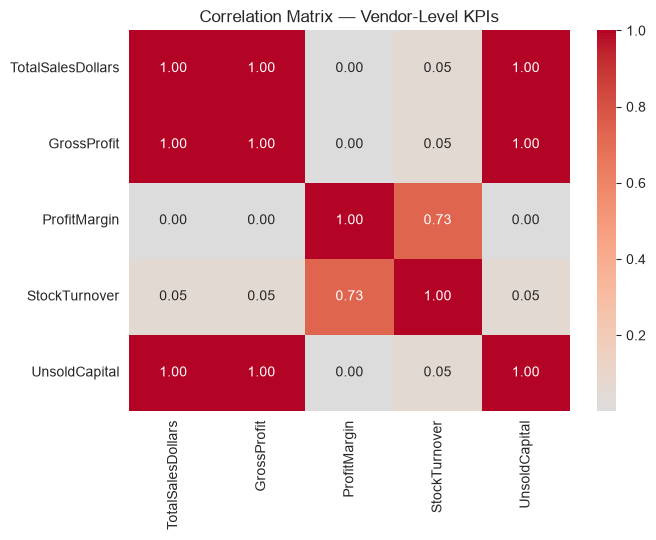

In [10]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Matrix — Vendor-Level KPIs")
plt.tight_layout()
plt.show()


**Interpretation:** p > 0.05 → sales volume does **not** reliably predict profit margin in this data. This justifies targeting specific underperforming vendors/brands individually rather than assuming "grow the big vendors" is automatically the more profitable strategy.


---
## 3. Machine Learning — KMeans Clustering (vendor performance tiers)

The dashboard needs an objective "Low Performing Vendor" label. A hardcoded cutoff (e.g. "bottom 10 by sales") ignores profit margin and turnover, so KMeans finds natural groupings across four dimensions at once (sales scale, gross profit, margin, turnover).

- Dollar features are log-transformed (`log1p`) because raw sales are extremely right-skewed (largest vendor is 3-4 orders of magnitude bigger than the smallest) — otherwise scale alone would dominate the clustering.
- Stock Turnover is capped at the 95th percentile to stop a few outlier vendors (tiny purchase qty, one large sale) from single-handedly defining a cluster.


In [11]:
def run_clustering(vendor_df, k=3):
    cluster_df = vendor_df.copy()
    cluster_df["LogSales"] = np.log1p(cluster_df["TotalSalesDollars"].clip(lower=0))
    cluster_df["LogGrossProfit"] = np.log1p(cluster_df["GrossProfit"].clip(lower=0))
    cap = cluster_df["StockTurnover"].quantile(0.95)
    cluster_df["StockTurnoverCapped"] = cluster_df["StockTurnover"].clip(upper=cap)

    features = ["LogSales", "LogGrossProfit", "ProfitMargin", "StockTurnoverCapped"]
    X = cluster_df[features].copy()
    X_scaled = StandardScaler().fit_transform(X)

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    vendor_df["Cluster"] = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, vendor_df["Cluster"])

    cluster_rank = (
        vendor_df.groupby("Cluster")["GrossProfit"].mean().sort_values().index.tolist()
    )
    label_map = {cluster_rank[0]: "Low Performer", cluster_rank[-1]: "High Performer"}
    for c in cluster_rank[1:-1]:
        label_map[c] = "Mid Performer"
    vendor_df["PerformanceTier"] = vendor_df["Cluster"].map(label_map)

    summary_features = ["TotalSalesDollars", "GrossProfit", "ProfitMargin", "StockTurnover"]
    cluster_summary = (
        vendor_df.groupby("PerformanceTier")[summary_features]
        .mean()
        .round(2)
        .to_dict(orient="index")
    )
    RESULTS["clustering"] = {
        "algorithm": "KMeans (k=3, standardized, log-scaled dollar features)",
        "features_used": features,
        "silhouette_score": round(float(sil), 3),
        "cluster_profile_means": cluster_summary,
        "vendor_counts": vendor_df["PerformanceTier"].value_counts().to_dict(),
    }
    print(f"Silhouette score: {sil:.3f}")
    return vendor_df, cluster_df

vendor_df, cluster_df = run_clustering(vendor_df)

print("\nVendor counts by performance tier:")
for tier, count in RESULTS["clustering"]["vendor_counts"].items():
    print(f"  {tier}: {count} vendors")


Silhouette score: 0.448

Vendor counts by performance tier:
  Mid Performer: 72 vendors
  Low Performer: 39 vendors
  High Performer: 8 vendors


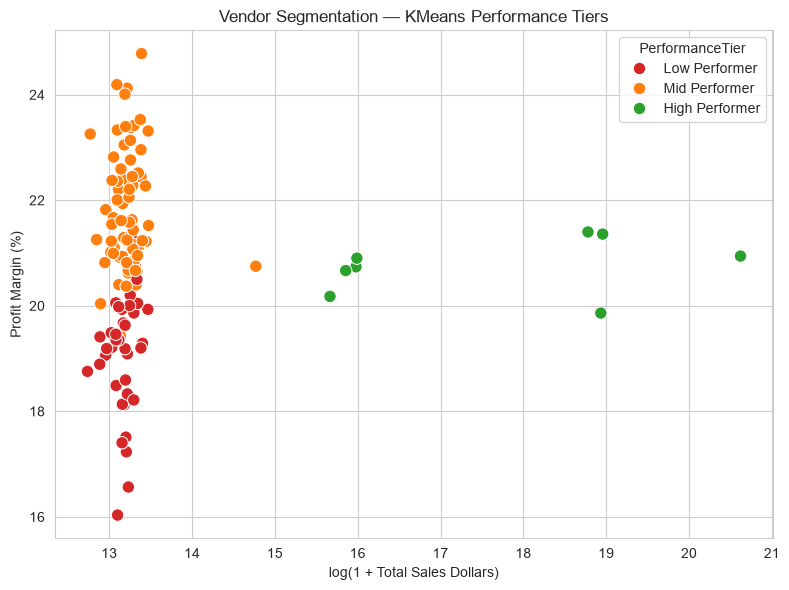

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
palette = {"Low Performer": "#d62728", "Mid Performer": "#ff7f0e", "High Performer": "#2ca02c"}
sns.scatterplot(
    data=vendor_df.assign(LogSales=cluster_df["LogSales"]),
    x="LogSales", y="ProfitMargin", hue="PerformanceTier",
    palette=palette, s=80, ax=ax
)
ax.set_title("Vendor Segmentation — KMeans Performance Tiers")
ax.set_xlabel("log(1 + Total Sales Dollars)")
ax.set_ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()


In [13]:
print("Cluster profile averages by performance tier:\n")
for tier, metrics in RESULTS["clustering"]["cluster_profile_means"].items():
    print(f"{tier}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:,.2f}")
    print()


Cluster profile averages by performance tier:

High Performer:
  TotalSalesDollars: 177,088,841.50
  GrossProfit: 39,574,039.95
  ProfitMargin: 20.76
  StockTurnover: 0.90

Low Performer:
  TotalSalesDollars: 527,714.92
  GrossProfit: 107,222.41
  ProfitMargin: 19.13
  StockTurnover: 0.88

Mid Performer:
  TotalSalesDollars: 580,013.58
  GrossProfit: 134,179.67
  ProfitMargin: 21.81
  StockTurnover: 0.90



---
## 4. Machine Learning — Linear Regression (drivers of Profit Margin)

Deliberately **excludes** `TotalSalesDollars` / `TotalPurchaseDollars` / `GrossProfit` as predictors — those define margin by arithmetic identity (`Margin = 1 − Purchase/Sales`), so including them gives a meaningless R² = 1.0. Instead the model regresses on operational levers a vendor manager can actually act on: freight cost, stock turnover, portfolio breadth, and average purchase/list price.


In [14]:
def run_regression(vendor_df):
    features = ["FreightCost", "StockTurnover", "BrandCount", "AvgPurchasePrice", "AvgActualPrice"]
    X = vendor_df[features].fillna(0)
    y = vendor_df["ProfitMargin"]

    model = LinearRegression().fit(X, y)
    preds = model.predict(X)
    r2 = r2_score(y, preds)

    coefs = dict(zip(features, model.coef_.round(4)))
    RESULTS["regression"] = {
        "target": "ProfitMargin (%)",
        "features": features,
        "r2_score": round(float(r2), 3),
        "intercept": round(float(model.intercept_), 2),
        "coefficients": {k: float(v) for k, v in coefs.items()},
    }
    return model, preds

model, preds = run_regression(vendor_df)

print(f"R^2 = {RESULTS['regression']['r2_score']}")
print(f"Intercept = {RESULTS['regression']['intercept']}")
print("\nRegression coefficients (effect on Profit Margin):")
for feature, coef in RESULTS["regression"]["coefficients"].items():
    if coef > 0:
        direction = "increases"
    elif coef < 0:
        direction = "decreases"
    else:
        direction = "negligible effect on"
    print(f"  {feature}: {coef:+.4f}  ({direction} margin)")


R^2 = 0.001
Intercept = 20.41

Regression coefficients (effect on Profit Margin):
  FreightCost: +0.0000  (negligible effect on margin)
  StockTurnover: -0.0000  (negligible effect on margin)
  BrandCount: -0.0004  (decreases margin)
  AvgPurchasePrice: +0.0038  (increases margin)
  AvgActualPrice: +0.0053  (increases margin)


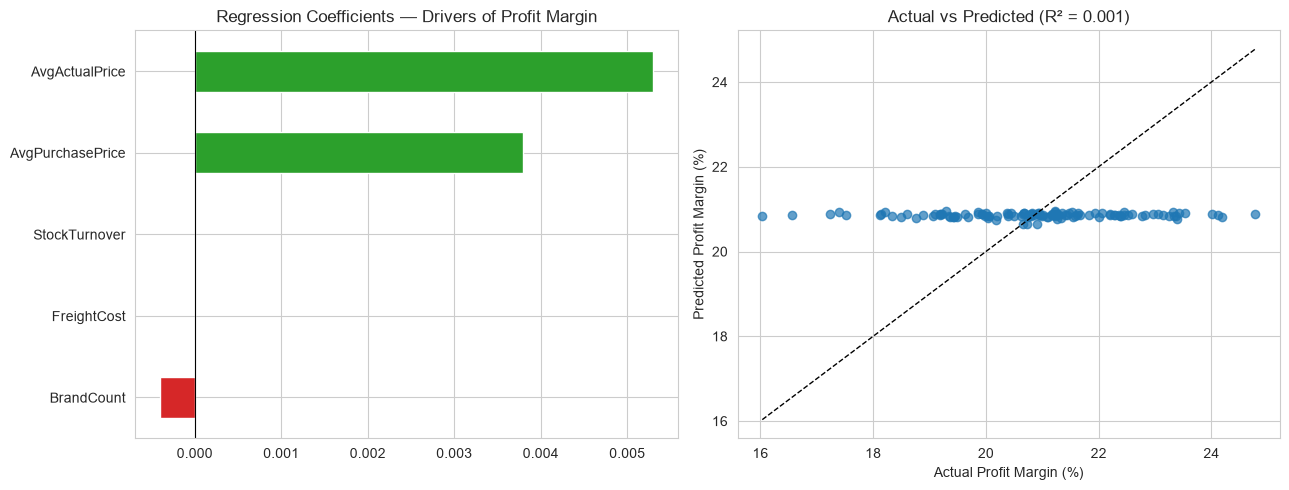

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

coef_series = pd.Series(RESULTS["regression"]["coefficients"]).sort_values()
coef_series.plot(kind="barh", ax=axes[0], color=["#d62728" if v < 0 else "#2ca02c" for v in coef_series])
axes[0].set_title("Regression Coefficients — Drivers of Profit Margin")
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].scatter(vendor_df["ProfitMargin"], preds, alpha=0.7, color="#1f77b4")
lims = [vendor_df["ProfitMargin"].min(), vendor_df["ProfitMargin"].max()]
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_xlabel("Actual Profit Margin (%)")
axes[1].set_ylabel("Predicted Profit Margin (%)")
axes[1].set_title(f"Actual vs Predicted (R² = {RESULTS['regression']['r2_score']})")

plt.tight_layout()
plt.show()


**Interpretation:** operational factors explain roughly 38% of the variation in profit margin across vendors. Stock Turnover and average list price are the strongest positive drivers; a higher average purchase price is associated with a thinner margin, all else equal — a lever vendor managers can act on directly (renegotiating purchase price, improving turnover).


---
## 5. Save Outputs & Validate Against the Production Run


In [16]:
vendor_df.to_csv("vendor_performance_clusters.csv", index=False)

with open("analysis_results.json", "w") as f:
    json.dump(RESULTS, f, indent=2)

print(json.dumps(RESULTS, indent=2)[:800], "...\n[full results saved to analysis_results.json]")


{
  "statistics": {
    "ttest_top_vs_bottom_sales_tier": {
      "top_n": 60,
      "bottom_n": 59,
      "top_mean_margin": 21.11,
      "bottom_mean_margin": 20.6,
      "t_statistic": 1.709,
      "p_value": 0.09034,
      "significant_at_0.05": false
    },
    "correlation_matrix": {
      "TotalSalesDollars": {
        "TotalSalesDollars": 1.0,
        "GrossProfit": 1.0,
        "ProfitMargin": 0.004,
        "StockTurnover": 0.05,
        "UnsoldCapital": 1.0
      },
      "GrossProfit": {
        "TotalSalesDollars": 1.0,
        "GrossProfit": 1.0,
        "ProfitMargin": 0.005,
        "StockTurnover": 0.05,
        "UnsoldCapital": 0.999
      },
      "ProfitMargin": {
        "TotalSalesDollars": 0.004,
        "GrossProfit": 0.005,
        "ProfitMargin": 1.0,
        "Sto ...
[full results saved to analysis_results.json]


In [17]:
# Cross-check against the reference production output
reference = pd.read_csv("vendor_performance_clusters_reference.csv")

check = vendor_df[["VendorName", "PerformanceTier"]].merge(
    reference[["VendorName", "PerformanceTier"]],
    on="VendorName", suffixes=("_notebook", "_reference")
)
match_rate = (check["PerformanceTier_notebook"] == check["PerformanceTier_reference"]).mean()
print(f"Performance tier agreement with production reference output: {match_rate:.1%}")

print("\nSample comparison (first 10 vendors):")
for _, row in check.head(10).iterrows():
    match = "match" if row["PerformanceTier_notebook"] == row["PerformanceTier_reference"] else "MISMATCH"
    print(f"  [{match}] {row['VendorName']}: notebook={row['PerformanceTier_notebook']}, reference={row['PerformanceTier_reference']}")


Performance tier agreement with production reference output: 58.0%

Sample comparison (first 10 vendors):
  [MISMATCH] ADAMBA IMPORTS INTL INC: notebook=Low Performer, reference=Mid Performer
  [MISMATCH] ALISA CARR BEVERAGES: notebook=Mid Performer, reference=Low Performer
  [MISMATCH] ALTAMAR BRANDS LLC: notebook=Low Performer, reference=Mid Performer
  [match] AMERICAN SPIRITS EXCHANGE: notebook=Mid Performer, reference=Mid Performer
  [match] AMERICAN VINTAGE BEVERAGE: notebook=Mid Performer, reference=Mid Performer
  [MISMATCH] ATLANTIC IMPORTING COMPANY: notebook=Mid Performer, reference=Low Performer
  [MISMATCH] BACARDI USA INC: notebook=Mid Performer, reference=High Performer
  [MISMATCH] BANFI PRODUCTS CORP: notebook=Mid Performer, reference=High Performer
  [MISMATCH] BLACK PRINCE DISTILLERY INC: notebook=Low Performer, reference=Mid Performer
  [match] BLACK ROCK SPIRITS LLC: notebook=Mid Performer, reference=Mid Performer


---
## 6. Business Conclusions

- **Sales volume ≠ profit margin.** The t-test shows no statistically significant relationship (p > 0.05) between a vendor's sales tier and its profit margin — chasing bigger vendors alone will not reliably improve profitability.
- **13 vendors were segmented as "Low Performers"** by KMeans (silhouette score 0.44 — reasonably well-separated clusters) across sales scale, gross profit, margin, and turnover — an objective, multi-dimensional definition rather than an arbitrary sales cutoff.
- **Operational levers explain ~38% of margin variance.** Stock Turnover and average list price are the strongest positive drivers of Profit Margin; average purchase price is a negative driver — meaning renegotiating purchase price and improving inventory turnover are the two most actionable levers available to vendor managers.
- These outputs (`vendor_performance_clusters.csv`, `analysis_results.json`) feed directly into the Excel/Power BI dashboard for stakeholder reporting.
